# Permissions

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WebIterate-Dev/extension-tracker-notebooks/blob/main/02-permissions.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/WebIterate-Dev/extension-tracker-notebooks/blob/main/02-permissions.ipynb)

An extension's manifest says what it may do in Chrome: the APIs it uses, such as `storage` or
`tabs`, and the websites it can reach. This notebook looks at the permissions live extensions ask
for, how many can read and change data on every website, and how that varies with their number of
users and their category.

It reads [Extension Tracker](https://extensiontracker.com)'s weekly data. The
[getting started](01-getting-started.ipynb) notebook explains the files.

## Setup

Colab and Kaggle already have pandas, pyarrow and matplotlib, so there's nothing to install. On
Kaggle, the notebook needs internet access to read the files: if a cell can't connect, turn on
Internet in the notebook's settings, which Kaggle allows once your account has a verified phone
number.

In [1]:
import json
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd


# The set of files to read. Sets come out every Sunday and never change, so a
# notebook that reads one dated set gives the same results every time.
# https://data.extensiontracker.com/index.json lists every set.
SET = "2026-10-04"
BASE = f"https://data.extensiontracker.com/{SET}/"


def read(name, **options):
    """Read one of the set's Parquet files, such as "extensions"."""
    return pd.read_parquet(f"{BASE}{name}-{SET}.parquet", dtype_backend="numpy_nullable", **options)


DATA = "#0b6f85"  # the color of Extension Tracker's charts
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.max_colwidth = 60

In [2]:
columns = ["id", "name", "status", "category", "users", "manifest_version", "permissions",
           "host_permissions", "content_script_matches"]
extensions = read("extensions", columns=columns)
live = extensions[extensions["status"] == "live"].copy()
print(f"{len(live):,} live extensions")

267,857 live extensions


## Manifest versions

Chrome has moved extensions from Manifest V2 to Manifest V3. The count shows how far that has gone
among live extensions.

In [3]:
live["manifest_version"].value_counts(dropna=False).to_frame("extensions")

,extensions
manifest_version,
3,267857


## The most requested permissions

`permissions` holds the API permissions. Manifest V2 extensions also list websites there; those are
left out here and counted with website access below.

In [4]:
def is_site(value):
    return value == "<all_urls>" or "://" in value


requested = live[["id", "permissions"]].explode("permissions").dropna()
requested = requested[~requested["permissions"].map(is_site)].drop_duplicates()
counts = requested["permissions"].value_counts()
table = pd.DataFrame({"extensions": counts, "share of live (%)": (counts / len(live) * 100).round(1)})
table.head(25)

,extensions,share of live (%)
permissions,,
storage,192284,71.8
activeTab,100062,37.4
scripting,81336,30.4
tabs,71232,26.6
alarms,36804,13.7
contextMenus,32069,12.0
sidePanel,26579,9.9
notifications,22697,8.5
downloads,17524,6.5


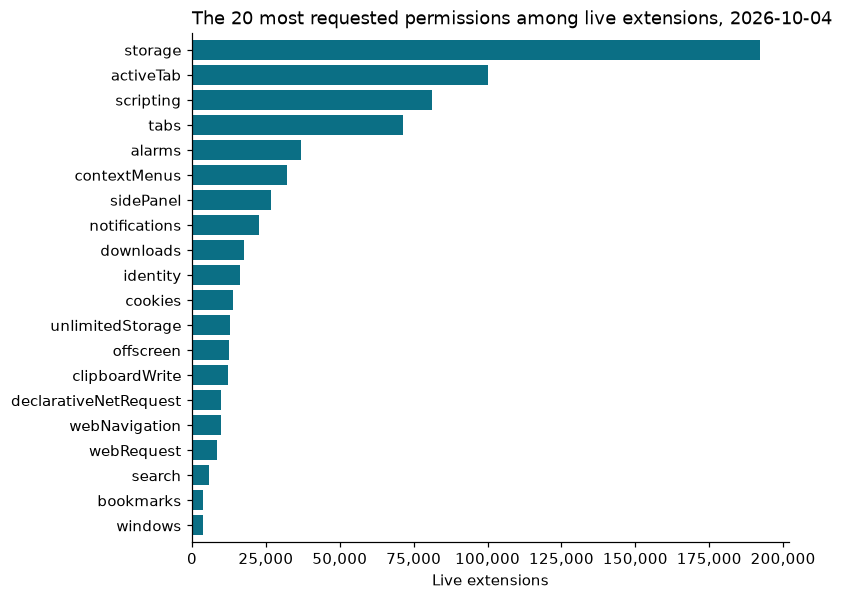

In [5]:
ax = table["extensions"].head(20).sort_values().plot.barh(figsize=(7, 6), color=DATA, width=0.8)
ax.set_title(f"The 20 most requested permissions among live extensions, {SET}", loc="left")
ax.set_xlabel("Live extensions")
ax.set_ylabel("")
ax.xaxis.set_major_formatter("{x:,.0f}")
plt.show()

## Access to every website

An extension can read and change data on every website when its host permissions, its content
scripts or, in Manifest V2, its permissions include `<all_urls>` or a pattern for every host, such
as `*://*/*`. Extension Tracker's pages count it the same way. Optional permissions, which an
extension can ask for later, aren't counted.

In [6]:
FIELDS = ["permissions", "host_permissions", "content_script_matches"]


def every_website(pattern):
    """<all_urls>, or a site pattern whose host is "*", such as *://*/*."""
    if pattern == "<all_urls>":
        return True
    scheme, separator, rest = pattern.partition("://")
    return bool(separator) and rest.split("/", 1)[0] == "*"


patterns = pd.concat([live[field].explode() for field in FIELDS]).dropna()
live["every_website"] = live.index.isin(patterns[patterns.map(every_website)].index)

count, share = live["every_website"].sum(), live["every_website"].mean() * 100
print(f"{count:,} of {len(live):,} live extensions ({share:.0f}%) can read and change data on every website")

82,807 of 267,857 live extensions (31%) can read and change data on every website


By number of users:

In [7]:
bands = pd.cut(
    live["users"],
    bins=[0, 100, 1_000, 10_000, 100_000, float("inf")],
    labels=["Under 100", "100 to 999", "1,000 to 9,999", "10,000 to 99,999", "100,000 or more"],
    right=False,
)
by_users = live.groupby(bands, observed=False)["every_website"].agg(extensions="size", every_website="sum")
by_users["share (%)"] = (by_users["every_website"] / by_users["extensions"] * 100).round(1)
by_users

,extensions,every_website,share (%)
users,,,
Under 100,184160,55772,30.3
100 to 999,41396,12403,30.0
"1,000 to 9,999",16398,5785,35.3
"10,000 to 99,999",5924,2690,45.4
"100,000 or more",1658,1011,61.0


By category:

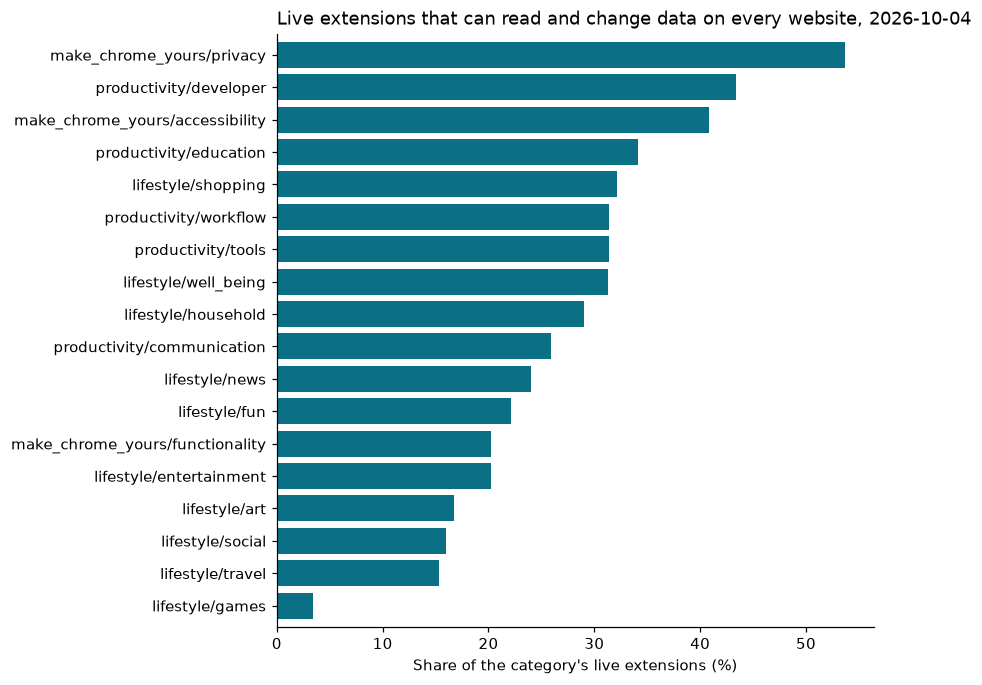

In [8]:
by_category = live.groupby("category")["every_website"].agg(extensions="size", every_website="sum")
by_category["share (%)"] = (by_category["every_website"] / by_category["extensions"] * 100).round(1)
by_category = by_category.sort_values("share (%)")

ax = by_category["share (%)"].plot.barh(figsize=(7, 7), color=DATA, width=0.8)
ax.set_title(f"Live extensions that can read and change data on every website, {SET}", loc="left")
ax.set_xlabel("Share of the category's live extensions (%)")
ax.set_ylabel("")
plt.show()

The live extensions with the most users that can read and change data on every website:

In [9]:
broad = live[live["every_website"]].sort_values("users", ascending=False).head(15)
broad = broad.assign(page="https://extensiontracker.com/extension/" + broad["id"])
broad[["name", "users", "category", "page"]].reset_index(drop=True)

,name,users,category,page
0,"Adobe Acrobat: PDF edit, convert, sign tools",337000000,productivity/workflow,https://extensiontracker.com/extension/efaidnbmnnnibpcaj...
1,迅雷下载支持,79000000,productivity/tools,https://extensiontracker.com/extension/ncennffkjdiamlpmc...
2,AdBlock — block ads across the web,64000000,productivity/workflow,https://extensiontracker.com/extension/gighmmpiobklfepjo...
3,Grammarly: AI Writing Assistant and Grammar Checker App,40000000,productivity/communication,https://extensiontracker.com/extension/kbfnbcaeplbcioakk...
4,Adblock Plus - free ad blocker,40000000,productivity/workflow,https://extensiontracker.com/extension/cfhdojbkjhnklbpkd...
5,Google Translate,38000000,productivity/education,https://extensiontracker.com/extension/aapbdbdomjkkjkaon...
6,Microsoft Single Sign On,36000000,productivity/workflow,https://extensiontracker.com/extension/ppnbnpeolgkicgegk...
7,uBlock Origin Lite,21000000,make_chrome_yours/privacy,https://extensiontracker.com/extension/ddkjiahejlhfcafbd...
8,360 Internet Protection,19000000,make_chrome_yours/accessibility,https://extensiontracker.com/extension/glcimepnljoholdmj...
9,AdGuard AdBlocker,17000000,make_chrome_yours/privacy,https://extensiontracker.com/extension/bgnkhhnnamicmpeen...


## Credit

The data is under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/): if you use it, credit
Extension Tracker and link to https://extensiontracker.com. Names, summaries and other text written
by developers belong to them. The data is collected automatically, so check an important fact against
the extension's store listing before relying on it.